# Task 1: Single-Layer LSTM for MNIST Classification — PyTorch

Each 28×28 image is treated as a sequence of **28 time steps**, each with a **28-dimensional feature vector** (one row per step).

**Architecture:** `LSTM(input=28, hidden=128)` → `FC(128 → 10)` → Softmax  
**Loss:** Cross-Entropy  
**Optimizer:** Adam (lr=1e-3)

## 1. Imports

In [1]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## 2. Load MNIST Data

In [2]:
def load_mnist_images(path):
    with open(path, 'rb') as f:
        magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
    return images.reshape(n, rows, cols).astype(np.float32) / 255.0

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels.astype(np.int64)

DATA_DIR = os.path.join(os.getcwd(), 'MNIST')

X_train = load_mnist_images(os.path.join(DATA_DIR, 'train-images.idx3-ubyte'))
y_train = load_mnist_labels(os.path.join(DATA_DIR, 'train-labels.idx1-ubyte'))
X_test  = load_mnist_images(os.path.join(DATA_DIR, 't10k-images.idx3-ubyte'))
y_test  = load_mnist_labels(os.path.join(DATA_DIR, 't10k-labels.idx1-ubyte'))

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (60000, 28, 28), Test: (10000, 28, 28)


## 3. Dataset & DataLoader

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

BATCH_SIZE = 128

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Using device: cpu
Train batches: 469, Test batches: 79


## 4. Model Definition

The model takes each image as a **sequence of 28 rows** (time steps), each row being a 28-dimensional vector.  

In [4]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_classes=10):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, seq_len=28, input_size=28)
        out, _ = self.lstm(x)    # out: (batch, seq_len, hidden_size)
        h_last = out[:, -1, :]   # last time step
        return self.fc(h_last)   # (batch, num_classes)

model = LSTMClassifier().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMClassifier(
  (lstm): LSTM(28, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 82,186


## 5. Optimizer & Loss

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Loss:      CrossEntropyLoss")
print("Optimizer: Adam  (lr=1e-3)")

Loss:      CrossEntropyLoss
Optimizer: Adam  (lr=1e-3)


## 6. Training Loop

In [6]:
EPOCHS = 10
train_losses, train_accs, test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * Xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += Xb.size(0)

    avg_loss  = epoch_loss / total
    train_acc = correct / total

    # Test accuracy
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            test_correct += (logits.argmax(dim=1) == yb).sum().item()
            test_total += Xb.size(0)
    test_acc = test_correct / test_total

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Epoch  1/10 | Loss: 0.6224 | Train Acc: 80.03% | Test Acc: 93.43%
Epoch  2/10 | Loss: 0.1623 | Train Acc: 95.22% | Test Acc: 95.42%
Epoch  3/10 | Loss: 0.1083 | Train Acc: 96.70% | Test Acc: 97.10%
Epoch  4/10 | Loss: 0.0816 | Train Acc: 97.53% | Test Acc: 97.64%
Epoch  5/10 | Loss: 0.0653 | Train Acc: 98.02% | Test Acc: 97.80%
Epoch  6/10 | Loss: 0.0580 | Train Acc: 98.26% | Test Acc: 98.16%
Epoch  7/10 | Loss: 0.0479 | Train Acc: 98.54% | Test Acc: 97.96%
Epoch  8/10 | Loss: 0.0437 | Train Acc: 98.65% | Test Acc: 98.00%
Epoch  9/10 | Loss: 0.0382 | Train Acc: 98.81% | Test Acc: 98.12%
Epoch 10/10 | Loss: 0.0340 | Train Acc: 98.93% | Test Acc: 98.29%

Final Test Accuracy: 98.29%


## 7. Plot Results

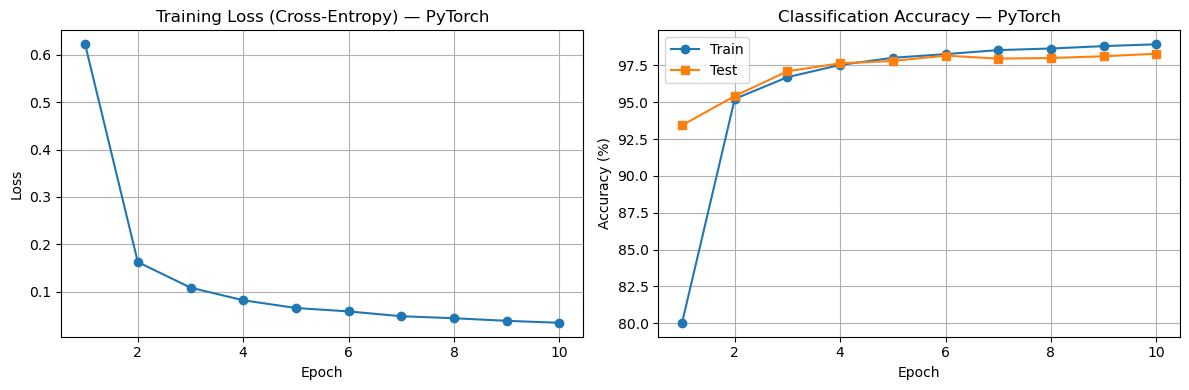

Plot saved to task1_lstm_results_pytorch.png


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS + 1), train_losses, marker='o')
ax1.set_title('Training Loss (Cross-Entropy) — PyTorch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, EPOCHS + 1), [a * 100 for a in train_accs], marker='o', label='Train')
ax2.plot(range(1, EPOCHS + 1), [a * 100 for a in test_accs],  marker='s', label='Test')
ax2.set_title('Classification Accuracy — PyTorch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('task1_lstm_results_pytorch.png', dpi=150)
plt.show()
print("Plot saved to task1_lstm_results_pytorch.png")

---
## Task 2: t-SNE + K-Means on LSTM Embeddings

The hidden state at the **last time step** (`h_last`, shape `128`) is the learned embedding for each image.

Steps:
1. Extract 128-dim embeddings for all 10 000 test images
2. Apply **t-SNE** to reduce to 2-D
3. Run **k-means (k=10)** on the 2-D coordinates
4. Plot data points (coloured by true label) and the 10 cluster centroids

In [8]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ── 1. Extract 128-dim embeddings ──────────────────────────────────────────────
model.eval()
embeddings = []
with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(device)
        out, _ = model.lstm(Xb)   # (batch, 28, 128)
        h_last = out[:, -1, :]    # (batch, 128)
        embeddings.append(h_last.cpu().numpy())

embeddings = np.concatenate(embeddings, axis=0)   # (10000, 128)
print(f'Embeddings shape: {embeddings.shape}')

Embeddings shape: (10000, 128)


In [10]:
# ── 2. t-SNE → 2-D ────────────────────────────────────────────────────────────
print('Running t-SNE')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
coords_2d = tsne.fit_transform(embeddings)   # (10000, 2)
print(f't-SNE output shape: {coords_2d.shape}')

Running t-SNE
t-SNE output shape: (10000, 2)


In [11]:
# ── 3. K-Means (k=10) on the 2-D coordinates ──────────────────────────────────
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(coords_2d)
centroids = kmeans.cluster_centers_           # (10, 2)
print(f'Cluster centroids shape: {centroids.shape}')

Cluster centroids shape: (10, 2)


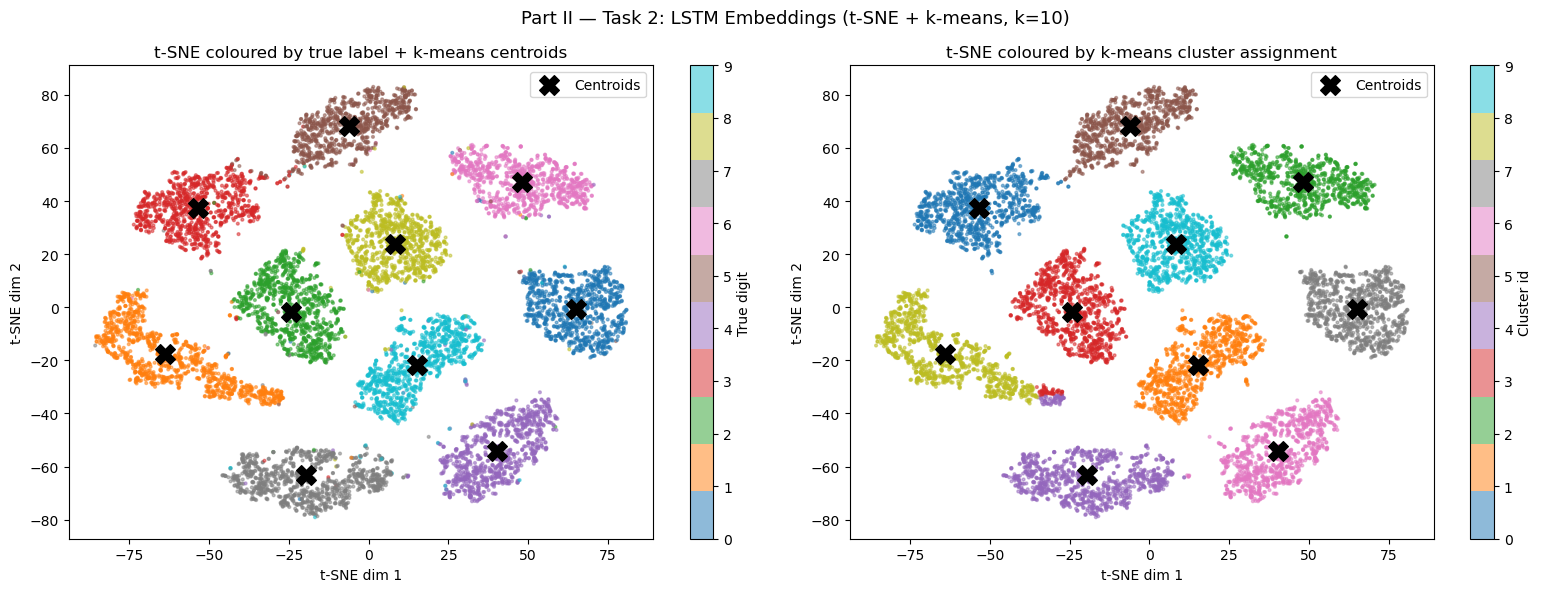

Plot saved to task2_lstm_tsne_kmeans.png


In [12]:
# ── 4. Scatter plot — true labels + cluster centroids ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cmap = plt.get_cmap('tab10')

# Left: coloured by TRUE digit label
sc = axes[0].scatter(coords_2d[:, 0], coords_2d[:, 1],
                     c=y_test, cmap='tab10', s=4, alpha=0.5)
axes[0].scatter(centroids[:, 0], centroids[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
plt.colorbar(sc, ax=axes[0], ticks=range(10), label='True digit')
axes[0].set_title('t-SNE coloured by true label + k-means centroids')
axes[0].set_xlabel('t-SNE dim 1')
axes[0].set_ylabel('t-SNE dim 2')
axes[0].legend()

# Right: coloured by CLUSTER assignment
sc2 = axes[1].scatter(coords_2d[:, 0], coords_2d[:, 1],
                      c=cluster_labels, cmap='tab10', s=4, alpha=0.5)
axes[1].scatter(centroids[:, 0], centroids[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
plt.colorbar(sc2, ax=axes[1], ticks=range(10), label='Cluster id')
axes[1].set_title('t-SNE coloured by k-means cluster assignment')
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')
axes[1].legend()

plt.suptitle('Part II — Task 2: LSTM Embeddings (t-SNE + k-means, k=10)', fontsize=13)
plt.tight_layout()
plt.savefig('task2_lstm_tsne_kmeans.png', dpi=150)
plt.show()
print('Plot saved to task2_lstm_tsne_kmeans.png')